### Install dependencies

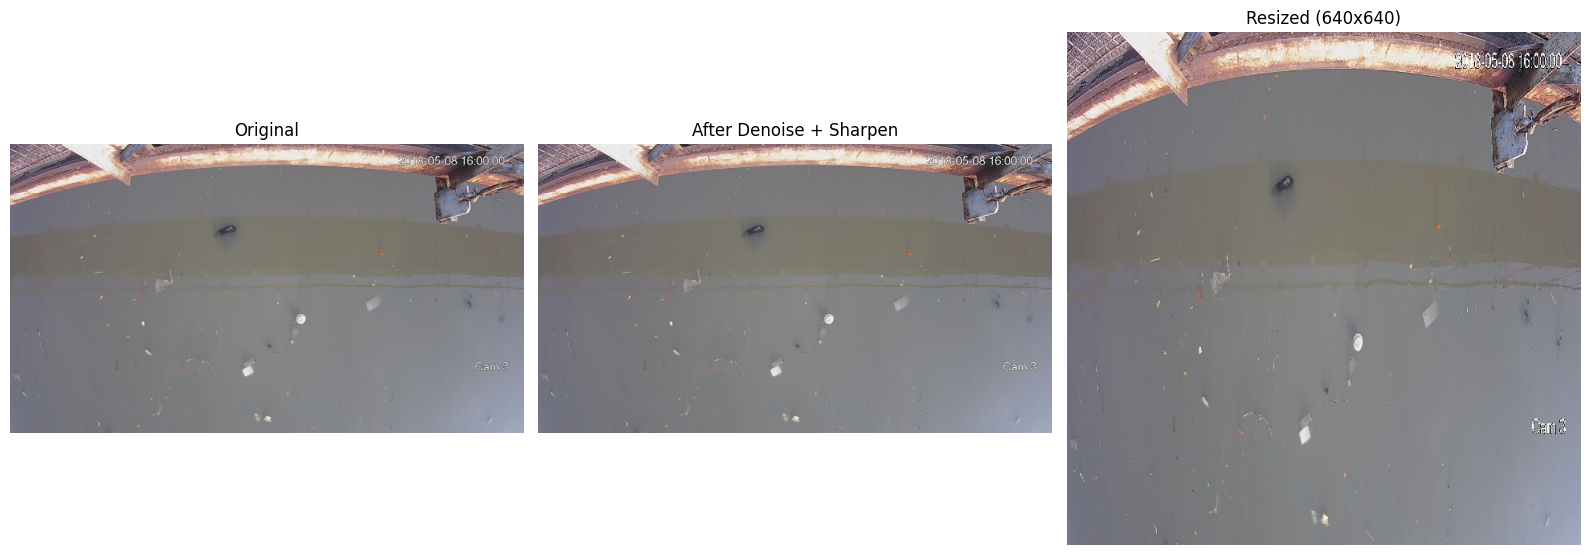

In [1]:
# dataset_75_15_10/train/images/00a45eba-Grogol_Location_3_2018-05-08_16-00-00-05_cam3.jpg
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load gambar ---
image = cv2.imread("dataset_75_15_10/train/images/00a45eba-Grogol_Location_3_2018-05-08_16-00-00-05_cam3.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# --- 1. Noise Removal (Gaussian Blur) ---
denoised = cv2.GaussianBlur(image, (5, 5), 0)

# --- 2. Sharpening (Unsharp Masking) ---
sharpened = cv2.addWeighted(image, 1.5, denoised, -0.5, 0)

# --- 3. Resize (misalnya ke 640x640 untuk YOLO) ---
resized = cv2.resize(sharpened, (640, 640))

# --- 4. Simpan hasil akhir ---
cv2.imwrite("preprocessed_image.jpg", resized)

# --- Tampilkan semua tahap ---
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
plt.title("After Denoise + Sharpen")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized (640x640)")
plt.axis("off")

plt.tight_layout()
plt.show()

### Preprocessing semua gambar

In [ ]:
import os
import cv2
import numpy as np
import shutil
from tqdm import tqdm

# Path dasar
input_base = "dataset_75_15_10"
output_base = "dataset_75_15_10_prepo"
target_size = (640, 640)

# Fungsi preprocessing
def preprocess_image(img):
    denoised = cv2.GaussianBlur(img, (5, 5), 0)
    sharpened = cv2.addWeighted(img, 1.5, denoised, -0.5, 0)
    resized = cv2.resize(sharpened, target_size)
    return resized

# Split yang akan diproses
splits = ["train", "valid", "test"]

for split in splits:
    print(f"\n🔧 Processing split: {split}")

    # Paths untuk images & labels
    input_image_folder = os.path.join(input_base, split, "images")
    input_label_folder = os.path.join(input_base, split, "labels")

    output_image_folder = os.path.join(output_base, split, "images")
    output_label_folder = os.path.join(output_base, split, "labels")

    # Buat folder output
    os.makedirs(output_image_folder, exist_ok=True)
    os.makedirs(output_label_folder, exist_ok=True)

    # === Proses gambar ===
    image_files = [f for f in os.listdir(input_image_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for filename in tqdm(image_files, desc=f"Processing images in {split}"):
        input_path = os.path.join(input_image_folder, filename)
        output_path = os.path.join(output_image_folder, filename)

        # Baca gambar
        image = cv2.imread(input_path)
        if image is None:
            print(f"❌ Failed to read {input_path}")
            continue

        # Preprocess dan simpan
        processed = preprocess_image(image)
        cv2.imwrite(output_path, processed)

    # === Copy label ===
    label_files = [f for f in os.listdir(input_label_folder) if f.endswith('.txt')]
    for label_file in label_files:
        src_label = os.path.join(input_label_folder, label_file)
        dst_label = os.path.join(output_label_folder, label_file)
        shutil.copy2(src_label, dst_label)

    print(f"✅ Done with {split}. {len(image_files)} images processed, {len(label_files)} labels copied.")


🔧 Processing split: train


Processing images in train: 100%|██████████| 1540/1540 [03:14<00:00,  7.93it/s]


✅ Done with train. 1540 images processed, 1540 labels copied.

🔧 Processing split: valid


Processing images in valid: 100%|██████████| 308/308 [00:36<00:00,  8.39it/s]


✅ Done with valid. 308 images processed, 308 labels copied.

🔧 Processing split: test


Processing images in test:  77%|███████▋  | 158/205 [00:22<00:05,  8.46it/s]

❌ Failed to read dataset_75_15_10\test\images\fa5a0e63-train814_-_副本.JPG


Processing images in test: 100%|██████████| 205/205 [00:29<00:00,  6.97it/s]


✅ Done with test. 205 images processed, 205 labels copied.


### Fungsi untuk Menghapus processed_images/

In [8]:
import shutil
import os

def delete_processed_images():
    """ Hapus semua folder processed_images dalam train, valid, test tanpa menghapus dataset asli """
    confirmation = input("❗ Apakah Anda yakin ingin menghapus semua processed_images? (yes/no): ").strip().lower()
    
    if confirmation == "yes":
        for subset in subsets:
            processed_folder = os.path.join(dataset_root, subset, "processed_images")

            # Hapus folder processed_images/ jika ada
            if os.path.exists(processed_folder):
                shutil.rmtree(processed_folder)
                print(f"✅ {processed_folder} berhasil dihapus.")
            else:
                print(f"ℹ️ {processed_folder} tidak ditemukan, tidak ada yang dihapus.")

        print("✅ Semua folder processed_images telah dihapus!")
    else:
        print("🚫 Penghapusan processed_images dibatalkan.")

# Jalankan untuk menghapus processed_images/
delete_processed_images()

✅ dataset_75_15_10\train\processed_images berhasil dihapus.
ℹ️ dataset_75_15_10\valid\processed_images tidak ditemukan, tidak ada yang dihapus.
ℹ️ dataset_75_15_10\test\processed_images tidak ditemukan, tidak ada yang dihapus.
✅ Semua folder processed_images telah dihapus!


### Cleaning dataset

In [ ]:
import os
import shutil

# Path asli dan path untuk dataset baru
source_base = 'dataset'
target_base = 'dataset_clean'
splits = ['train', 'valid', 'test']

# Ekstensi gambar yang mungkin
image_exts = ['.jpg', '.jpeg', '.png']

for split in splits:
    print(f"\n=== Proses folder: {split} ===")
    
    src_images = os.path.join(source_base, split, 'images')
    src_labels = os.path.join(source_base, split, 'labels')
    
    dst_images = os.path.join(target_base, split, 'images')
    dst_labels = os.path.join(target_base, split, 'labels')
    
    # Buat folder baru jika belum ada
    os.makedirs(dst_images, exist_ok=True)
    os.makedirs(dst_labels, exist_ok=True)

    copied_count = 0
    skipped_count = 0

    for label_file in os.listdir(src_labels):
        label_path = os.path.join(src_labels, label_file)

        if os.path.getsize(label_path) == 0:
            skipped_count += 1
            continue

        # Copy label file
        shutil.copy(label_path, os.path.join(dst_labels, label_file))

        # Cari dan copy gambar yang sesuai
        image_name = os.path.splitext(label_file)[0]
        found = False
        for ext in image_exts:
            image_path = os.path.join(src_images, image_name + ext)
            if os.path.exists(image_path):
                shutil.copy(image_path, os.path.join(dst_images, image_name + ext))
                found = True
                copied_count += 1
                break

        if not found:
            print(f"⚠️  Gambar untuk label {label_file} tidak ditemukan!")

    print(f"✅ Disalin (valid): {copied_count}")
    print(f"❌ Dilewati (label kosong): {skipped_count}")


=== Proses folder: train ===
✅ Disalin (valid): 1310
❌ Dilewati (label kosong): 127

=== Proses folder: valid ===
✅ Disalin (valid): 363
❌ Dilewati (label kosong): 48

=== Proses folder: test ===
✅ Disalin (valid): 190
❌ Dilewati (label kosong): 15


### Membuat beberapa label kosong

In [8]:
import os
import shutil
import random
import math

# Konfigurasi
source_base = 'withoutgrogol'
target_base = 'withoutgrogol_random_empty'

# Persentase label yang ingin dikosongkan per split
percentage_to_empty = {
    'train': 10,   # dalam persen
    'valid': 10,
    'test': 10
}

# 1. Salin seluruh dataset ke folder baru
if os.path.exists(target_base):
    print(f"Folder '{target_base}' sudah ada. Menghapus dan mengganti...")
    shutil.rmtree(target_base)

shutil.copytree(source_base, target_base)
print(f"✅ Dataset berhasil disalin ke '{target_base}'")

# 2. Kosongkan file label sesuai persentase
for split, percentage in percentage_to_empty.items():
    labels_path = os.path.join(target_base, split, 'labels')
    all_labels = [f for f in os.listdir(labels_path) if f.endswith('.txt')]

    n_total = len(all_labels)
    n_empty = math.ceil((percentage / 100) * n_total)

    # Pilih file secara acak
    selected = random.sample(all_labels, min(n_empty, n_total))

    for label_file in selected:
        label_path = os.path.join(labels_path, label_file)
        with open(label_path, 'w') as f:
            f.write('')  # kosongkan isi file

    print(f"\n📁 Split: {split}")
    print(f"Total file label      : {n_total}")
    print(f"Dikosongkan ({percentage}%) : {len(selected)} file")
    for f in selected:
        print(f"- {f}")


✅ Dataset berhasil disalin ke 'withoutgrogol_random_empty'

📁 Split: train
Total file label      : 1144
Dikosongkan (10%) : 115 file
- 8918c236-train1013.txt
- 4f9754b7-131.txt
- 26c4070e-train1157.txt
- a3570bd3-train438.txt
- 0abbf1e3-train595.txt
- 12a65da0-train948.txt
- 3783b00a-train23.txt
- 950692e0-train858.txt
- 780fb68d-train632.txt
- bb12b2e0-train208.txt
- 7deaf9e5-train308.txt
- 2f1822b8-train26.txt
- 4f69d132-train254.txt
- 72384c27-train408.txt
- 9bbbe5e8-train1101.txt
- b18f4310-train224.txt
- 76a04cf8-140.txt
- 26944b95-train74.txt
- 4ae67daf-train665.txt
- 2d6d1eb3-train788.txt
- 93793f9d-train301.txt
- 3cb3a319-train900.txt
- af783955-train1155.txt
- 430eaae5-train692.txt
- 5a695cbe-train114.txt
- 61e1f2ec-train1200.txt
- 3ebffc5d-train568.txt
- 5fd66f0b-244.txt
- a35dc0d2-train917.txt
- 05b19578-train430.txt
- 00ac5a0a-train1074.txt
- 0d93e5ad-train395.txt
- a274c85e-train803.txt
- 6be359c8-train782.txt
- 8d8ab852-train489.txt
- 981b5c46-train352.txt
- 93a4be61-trai

### Cek Label Kosong

In [7]:
import os

# Path dataset
base_path = 'dataset'
splits = ['train', 'valid', 'test']

empty_files_by_split = {}
total_empty = 0

for split in splits:
    labels_path = os.path.join(base_path, split, 'labels')
    split_empty = []

    for label_file in os.listdir(labels_path):
        label_path = os.path.join(labels_path, label_file)

        # Cek apakah label kosong
        if os.path.getsize(label_path) == 0:
            split_empty.append(label_file)
    
    empty_files_by_split[split] = split_empty
    total_empty += len(split_empty)

# Output hasil pengecekan per split
for split, files in empty_files_by_split.items():
    print(f"\n🔎 Split: {split}")
    if files:
        print(f"Ditemukan {len(files)} file label kosong:")
        for file in files:
            print(f"- {split}/labels/{file}")
    else:
        print("Tidak ada file label kosong.")

# Total keseluruhan
print(f"\n📊 Total file label kosong di seluruh dataset: {total_empty}")


🔎 Split: train
Ditemukan 127 file label kosong:
- train/labels/00a45eba-Grogol_Location_3_2018-05-08_16-00-00-05_cam3.txt
- train/labels/019f1d1d-Grogol_Location_3_2018-05-08_15-45-00-05_cam3.txt
- train/labels/027660d6-Grogol_Location_3_2018-05-03_11-30-00-05_cam8.txt
- train/labels/042e3f2e-Grogol_Location_2_2018-05-11_15-45-00-05_cam2.txt
- train/labels/06ae4622-Grogol_Location_3_2018-05-03_13-30-00-05_cam8.txt
- train/labels/0780bf82-Grogol_Location_3_2018-05-08_10-15-00-05_cam3.txt
- train/labels/0b02436e-Grogol_Location_4_2018-05-04_12-30-00-05_cam8.txt
- train/labels/0cad0158-Grogol_Location_4_2018-05-03_13-45-00-05_cam9.txt
- train/labels/0dc864a1-Grogol_Location_3_2018-05-08_17-15-00-05_cam3.txt
- train/labels/11137f87-Grogol_Location_3_2018-05-08_14-45-00-05_cam3.txt
- train/labels/115f5437-Grogol_Location_4_2018-05-02_15-15-00-05_cam9.txt
- train/labels/13dc340b-Grogol_Location_3_2018-05-07_10-45-00-05_cam3.txt
- train/labels/14bbd02c-Grogol_Location_4_2018-05-03_11-30-00-0